### Building our dataset for
### <b>PL<span style="color: red;">i</span>Cat </b>(<b>P</b>rotein–<b>L</b>ipid <span style="color: red;"><b>i</b></span>nteraction <b>Ca</b>tegorization <b>T</b>ool)
We perform data discovery, extraction, filtering, cleaning, verification, and processing for our projects.
<div style="text-align: right;"><em><b>by Feitong Dong</b><br>
June 2025</em></div>

## 3 Clean Data
#### <b>3.1</b> Clean the rows where the sequence contains '('and 'protein_UniProt_ID' is empty

In [14]:
df = pd.read_csv("./dataset/lipid_protein_4_columns_grouped.csv")
# Constructing deletion conditions
condition = df['protein_UniProt_ID'].isna() & df['protein_Sequence'].str.contains(r'\(', na=False)

# Delete the rows that match the condition
df_cleaned = df[~condition]

# Save as a new file
df_cleaned.to_csv("./dataset/lipid_protein_4_columns_grouped_without_Parentheses.csv", index=False)

print("Saved as: ./dataset/lipid_protein_4_columns_grouped_without_Parentheses.csv")

Saved as: ./dataset/lipid_protein_4_columns_grouped_without_Parentheses.csv


In [15]:
len(df_cleaned)

19506

In [16]:
df_cleaned.isnull().sum()

BioDolphinID                     0
protein_UniProt_ID            1156
protein_Sequence                 0
lipid_Lipidmaps_categories       0
dtype: int64

#### <b>3.2</b> Find the correct sequence from the <b>UniProt database</b>
(XXX) in a protein sequence usually means "these three amino acids are not part of the natural main sequence". They may be tags, signal peptide residues, non-standard amino acids, predicted complementary fragments, etc. They are commonly found at the N-terminus or C-terminus and their function is to distinguish the main functional region from additional sequences.<br/>
Find these sequences and replace them with the corresponding full sequences in the<b> UniProt database</b> according to their <b>protein_UniProt_ID</b>.

In [17]:
# Load the dataset
df = pd.read_csv("./dataset/lipid_protein_4_columns_grouped_without_Parentheses.csv")

# Filter rows where 'protein_Sequence' contains '('
filtered_df = df[df['protein_Sequence'].str.contains(r'\(', na=False)]

# Keep only the 'protein_UniProt_ID' and 'BioDolphinID' columns
result_df = filtered_df[['protein_UniProt_ID', 'BioDolphinID']]

# Save the result
output_path = "./dataset/UniProtID_BioDolphinID.csv"
result_df.to_csv(output_path, index=False)

print(f"Extracted 'protein_UniProt_ID' and 'BioDolphinID' from rows where 'protein_Sequence' contains '(', saved to: {output_path}")


Extracted 'protein_UniProt_ID' and 'BioDolphinID' from rows where 'protein_Sequence' contains '(', saved to: ./dataset/UniProtID_BioDolphinID.csv


In [18]:
len(result_df)

862

In [19]:
result_df.isnull().sum()

protein_UniProt_ID    0
BioDolphinID          0
dtype: int64

In [21]:
df.isnull().sum()

BioDolphinID                     0
protein_UniProt_ID            1156
protein_Sequence                 0
lipid_Lipidmaps_categories       0
dtype: int64

In [23]:
len(result)

16112

In [24]:
result.isnull().sum()

BioDolphinID                    0
protein_UniProt_ID            880
protein_Sequence                0
lipid_Lipidmaps_categories      0
dtype: int64

In [25]:
# Load process_data
df = pd.read_csv("./dataset/lipid_protein_4_columns_grouped_Combined_lipid.csv")  

# Define processing function
def dedup_categories(entry):
    # Handle NaN values to avoid errors
    if pd.isna(entry):
        return entry
    
    # Split -> strip whitespace -> remove duplicates -> preserve order
    items = [item.strip() for item in entry.split(',')]
    seen = set()
    unique_items = []
    for item in items:
        if item not in seen:
            seen.add(item)
            unique_items.append(item)
    return ', '.join(unique_items)

# Apply to lipid_Lipidmaps_categories column
df['lipid_Lipidmaps_categories_cleaned'] = df['lipid_Lipidmaps_categories'].apply(dedup_categories)

# Save results (overwriting original file)
output_path = "./dataset/lipid_protein_4_columns_grouped_Combined_lipid.csv"
df.to_csv(output_path, index=False)

print(f"Deduplicated process_data saved to: {output_path}")


Deduplicated process_data saved to: ./dataset/lipid_protein_4_columns_grouped_Combined_lipid.csv


In [27]:
df.isnull().sum()

BioDolphinID                    0
protein_UniProt_ID            880
protein_Sequence                0
lipid_Lipidmaps_categories      0
dtype: int64

In [28]:
# 1. Read two process_data tables
df_main = pd.read_csv("./dataset/lipid_protein_4_columns_grouped_Combined_lipid.csv")
df_uniprot = pd.read_csv("./dataset/Total_UniProtID_Sequence.csv")  # Should contain 'protein_UniProt_ID' and 'UniProt_sequence' columns

# 2. Identify rows containing '(' (we need to replace protein_Sequence in these rows)
mask = df_main['protein_Sequence'].str.contains(r'\(', na=False)

# 3. Merge rows containing '(' with UniProt process_data table (left join)
df_update = df_main[mask].merge(
    df_uniprot,
    how='left',
    on='protein_UniProt_ID'
)

# 4. Replace original protein_Sequence with merged UniProt_sequence (only for these rows)
df_main.loc[mask, 'protein_Sequence'] = df_update['UniProt_sequence'].values

# 5. Save the result
output_path = "./dataset/lipid_protein_4_columns_grouped_Combined_lipid_Replaced.csv"
df_main.to_csv(output_path, index=False)

print(f"Replaced protein_Sequence containing '(', results saved to: {output_path}")
    

Replaced protein_Sequence containing '(', results saved to: ./dataset/lipid_protein_4_columns_grouped_Combined_lipid_Replaced.csv


In [29]:
df_main.columns

Index(['BioDolphinID', 'protein_UniProt_ID', 'protein_Sequence',
       'lipid_Lipidmaps_categories'],
      dtype='object')

In [30]:
df_main.isnull().sum()

BioDolphinID                    0
protein_UniProt_ID            880
protein_Sequence                0
lipid_Lipidmaps_categories      0
dtype: int64

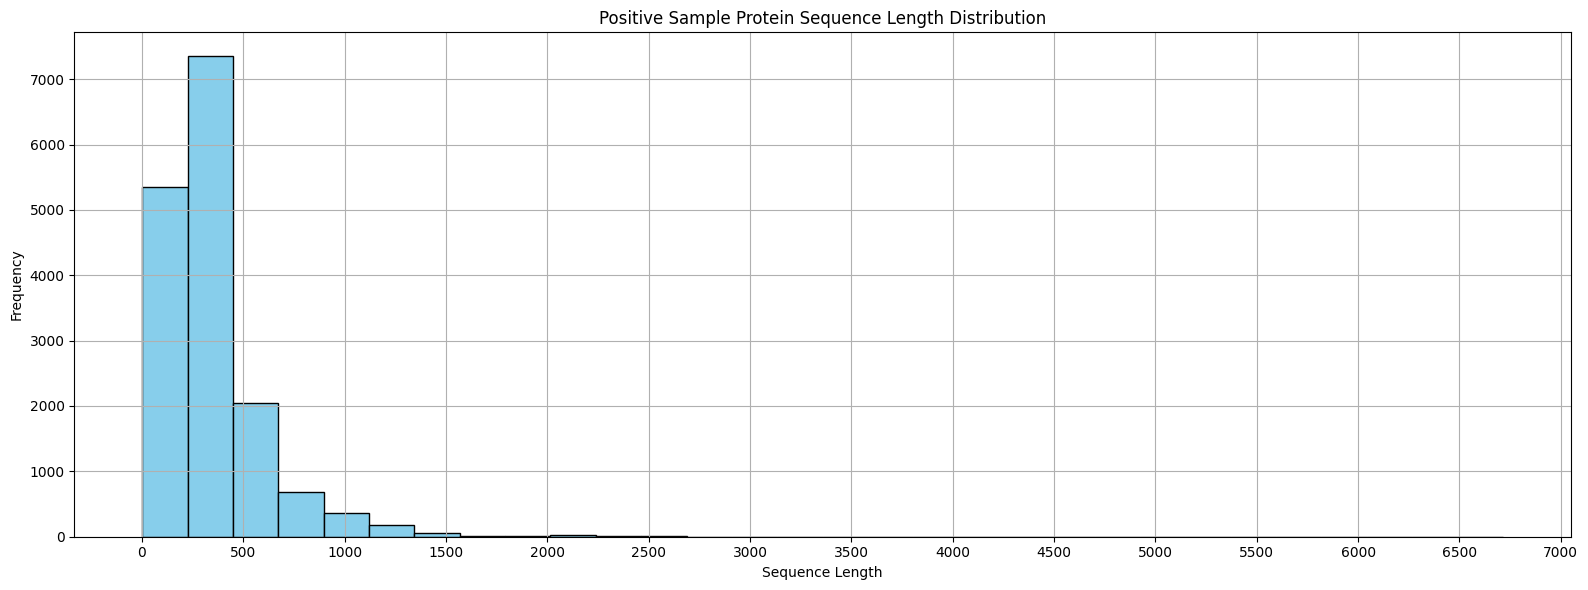

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load process_data from CSV file
df = pd.read_csv("./dataset/lipid_protein_4_columns_grouped_Combined_lipid_Replaced.csv")

# Calculate protein sequence lengths
df["Sequence_length"] = df["protein_Sequence"].astype(str).apply(len)

# Plot histogram of sequence lengths
plt.figure(figsize=(16, 6))
plt.hist(df["Sequence_length"], bins=30, color="skyblue", edgecolor="black")
plt.title("Positive Sample Protein Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(True)

# Set x-axis tick interval to 500
max_len = df["Sequence_length"].max()
xticks = np.arange(0, max_len + 500, 500)
plt.xticks(xticks)
plt.tight_layout()
# Save image 
plt.savefig("./dataset/images/Positive_protein_sequence_length_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

Select sequences with a length range of<b> [35,500] </b>as our dataset

In [32]:
import pandas as pd

# Read CSV file
df = pd.read_csv('./dataset/lipid_protein_4_columns_grouped_Combined_lipid_Replaced.csv')

# Calculate sequence lengths and filter records between 35-500 (inclusive)
df = df[df['protein_Sequence'].str.len().between(35, 500, inclusive='both')]

# Save to new file
output_path = './dataset/lipid_protein_4_columns_35_500.csv'
df.to_csv(output_path, index=False)

print(f"Extraction completed! A total of {len(df)} records have been filtered and saved to the specified path.")
    

Extraction completed! A total of 13250 records have been filtered and saved to the specified path.


##### Delete invalid sequences of all "A"

Observe the data set after filtering by length, the sequence length is close to normal distribution, which is exactly what we need.

In [35]:
# Rename column
df.rename(columns={"protein_Sequence": "Sequence"}, inplace=True)

# Save to new file 
output_path = "./dataset/lipid_protein_4_columns_35_500.csv"
df.to_csv(output_path, index=False)

print(f"Column name has been changed from 'protein_Sequence' to 'Sequence' and saved to: {output_path}")
    

Column name has been changed from 'protein_Sequence' to 'Sequence' and saved to: ./dataset/lipid_protein_4_columns_35_500.csv


In [36]:
df_main.columns

Index(['BioDolphinID', 'protein_UniProt_ID', 'protein_Sequence',
       'lipid_Lipidmaps_categories'],
      dtype='object')

In [37]:
len(df_main)

16112

In [38]:
df_main.isnull().sum()

BioDolphinID                    0
protein_UniProt_ID            880
protein_Sequence                0
lipid_Lipidmaps_categories      0
dtype: int64

## 4 Processing our negative sample dataset
The negative sample dataset was independently extracted from the UniProt database.

In [39]:
import pandas as pd
df = pd.read_csv('./dataset/no_lipid_binding_proteins_filtered.csv')
df.columns

Index(['Entry', 'Entry Name', 'PDB', 'PDBsum', 'Sequence', 'Binding site',
       'Protein names', 'Organism', 'Lipidation', 'Subcellular location [CC]',
       'Pfam'],
      dtype='object')

In [40]:
df.isnull().sum()

Entry                            0
Entry Name                       0
PDB                              0
PDBsum                           0
Sequence                         0
Binding site                 12086
Protein names                    0
Organism                         0
Lipidation                   12086
Subcellular location [CC]        0
Pfam                           591
dtype: int64

#### <b>4.1</b> Further cleaning of negative sample dataset

In [41]:
import pandas as pd

# load the process_data
df = pd.read_csv('./dataset/no_lipid_binding_proteins_filtered.csv')

# Convert all fields to strings and check if any element contains "lipo", "lipid", "fatty", or "Polyketides"
mask = df.apply(lambda row: row.astype(str).str.contains('lipo|lipid|fatty|Polyketides', case=False, na=False)).any(axis=1)

# Remove rows containing the keywords
df_cleaned = df[~mask]

# Optional: Save as a new file
df_cleaned.to_csv('./dataset/no_lipid_binding_proteins_cleaned.csv', index=False)

print(f"Original number of rows: {len(df)}, number of rows after cleaning: {len(df_cleaned)}")
    

Original number of rows: 12086, number of rows after cleaning: 11991


In [42]:
df = pd.read_csv('./dataset/no_lipid_binding_proteins_cleaned.csv')
df = df[['Entry','Sequence']]
df.to_csv('./dataset/no_lipid_binding_proteins.csv', index=False)
print(f"rows：{len(df)}")

rows：11991


In [43]:
import pandas as pd

# Read the two process_data tables
df1 = pd.read_csv('./dataset/no_lipid_binding_proteins.csv')  # Contains 'Entry' column
df2 = pd.read_csv('./dataset/lipid_protein_14_columns.csv')  # Contains 'protein_UniProt_ID' column

# Get the intersection of the two columns' values
matching_ids = set(df1['Entry']) & set(df2['protein_UniProt_ID'])

# Filter matching records from df1
matched_rows1 = df1[df1['Entry'].isin(matching_ids)]

# Filter matching records from df2
matched_rows2 = df2[df2['protein_UniProt_ID'].isin(matching_ids)]

# Print number of matching rows
print(f"There are {len(matched_rows1)} matching records in both tables.")
matched_rows1.to_csv('./dataset/matched_proteins1.csv', index=False)
print(f"There are {len(matched_rows2)} matching records in both tables.")
matched_rows2.to_csv('./dataset/matched_proteins2.csv', index=False)
    

There are 910 matching records in both tables.
There are 27931 matching records in both tables.


Delete 910 records from negative samples that are identical to positive samples

In [44]:
import pandas as pd

# Read two tables
df = pd.read_csv('./dataset/no_lipid_binding_proteins.csv')  # Original table containing Entry column
matched_df = pd.read_csv('./dataset/matched_proteins1.csv')  # Contains Entry values to be removed

# Get the set of Entry values to remove
entries_to_remove = set(matched_df['Entry'])

# Remove matching rows
df_filtered = df[~df['Entry'].isin(entries_to_remove)]

# Save the result (optional)
df_filtered.to_csv('./dataset/no_lipid_binding_proteins.csv', index=False)

# Print removal results
print(f"Original row count: {len(df)}, Row count after removal: {len(df_filtered)}, Total removed: {len(df) - len(df_filtered)} rows.")

Original row count: 11991, Row count after removal: 11081, Total removed: 910 rows.


#### <b>4.2</b> Observe the distribution of negative sample lengths

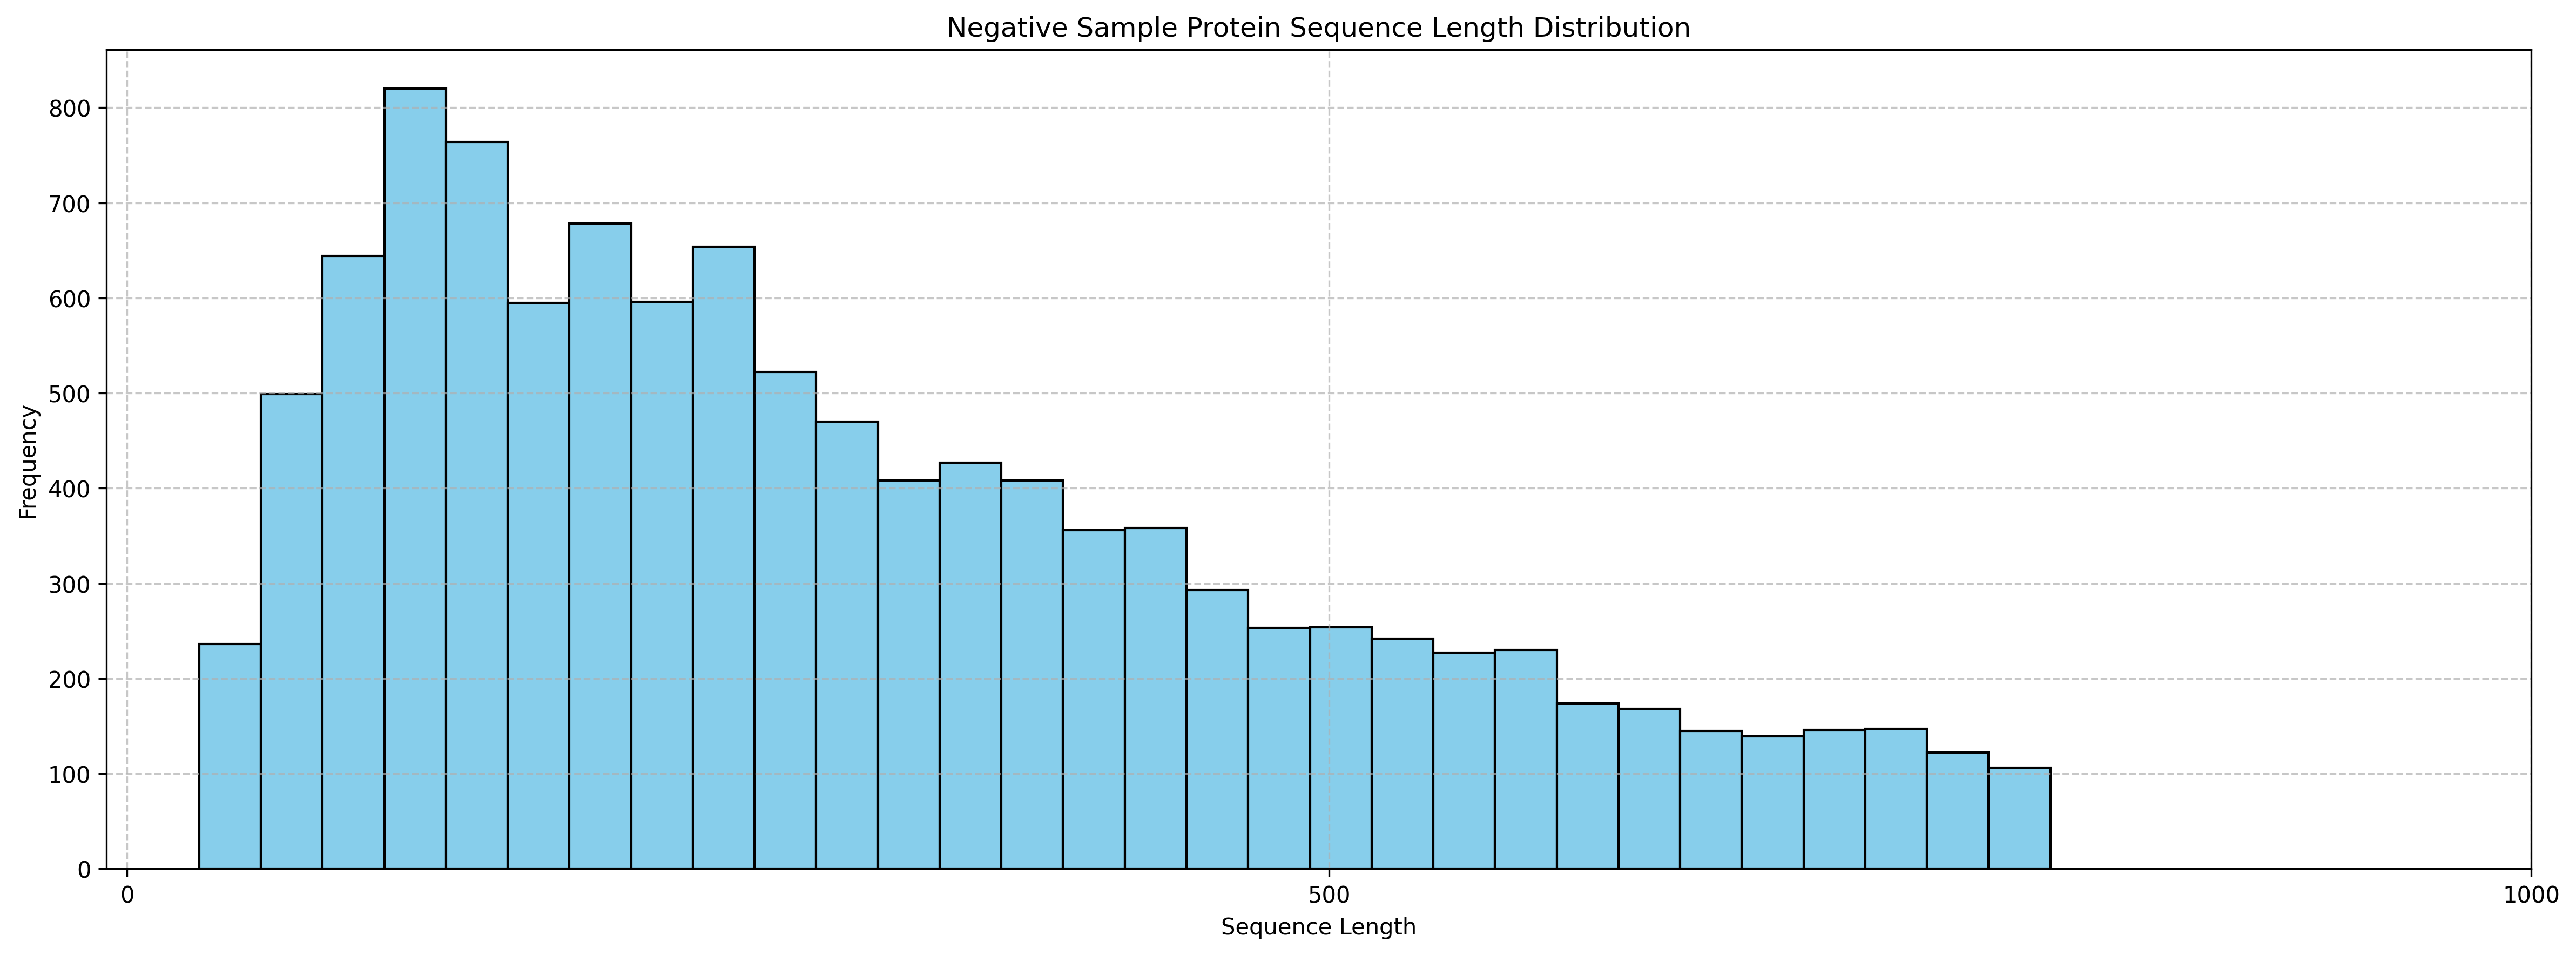

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the process_data
df = pd.read_csv("./dataset/no_lipid_binding_proteins.csv")

# Calculate protein sequence lengths
df["Sequence_length"] = df["Sequence"].astype(str).apply(len)

# Create histogram
plt.figure(figsize=(16, 6), dpi=300)  # Set high resolution (300 dpi)
plt.hist(df["Sequence_length"], bins=30, color="skyblue", edgecolor="black")
plt.title("Negative Sample Protein Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.7)

# Set x-axis tick interval to 500
max_len = df["Sequence_length"].max()
xticks = np.arange(0, max_len + 500, 500)
plt.xticks(xticks) 

plt.tight_layout()

# Save image 
plt.savefig("./dataset/images/Negative_protein_sequence_length_distribution.png", dpi=300, bbox_inches='tight')

plt.show()


In [46]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('./dataset/no_lipid_binding_proteins.csv')

# Calculate sequence lengths and filter records where length is between 35 and 500 (inclusive)
df = df[df['Sequence'].str.len().between(35, 500, inclusive='both')]

# Save to a new file
df.to_csv('./dataset/no_lipid_binding_proteins_35_500.csv', index=False)

print(f"Extraction completed! A total of {len(df)} records were filtered and saved to the specified path.")

Extraction completed! A total of 9019 records were filtered and saved to the specified path.


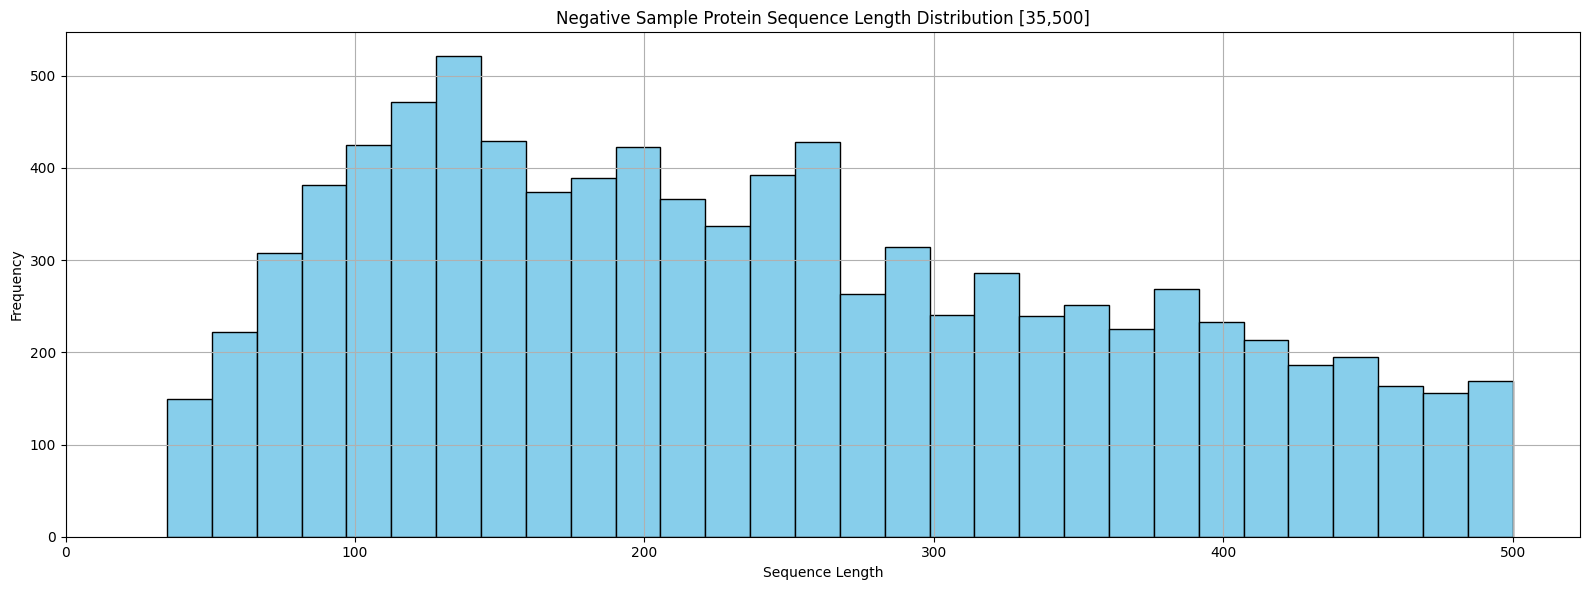

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the process_data
df = pd.read_csv("./dataset/no_lipid_binding_proteins_35_500.csv")

# Calculate protein sequence lengths
df["sequence_length"] = df["Sequence"].astype(str).apply(len)

# Plot histogram
plt.figure(figsize=(16, 6))
plt.hist(df["sequence_length"], bins=30, color="skyblue", edgecolor="black")
plt.title("Negative Sample Protein Sequence Length Distribution [35,500]")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(True)
# Set x-axis tick interval to 100
max_len = df["sequence_length"].max()
xticks = np.arange(0, max_len + 100, 100)
plt.xticks(xticks)
plt.tight_layout()
plt.savefig("./dataset/images/Negative_protein_sequence_length_distribution35_500.png", dpi=300, bbox_inches='tight')
plt.show()

#### 4.3 Deduplication (clustering) of protein sequences using CD-HIT

CD-HIT was used to deduplicate (cluster) protein sequences. We selected an identity threshold of 70%.
- Relatively close homologous sequences were removed to emphasize broader diversity.
- This approach is suitable for machine learning model training, avoiding overfitting to highly similar sequences.
- It helps improve model generalization and predictive power.

##### Convert negative sample csv file to fasta file

【1】Copy the FASTA files from the Windows system to the Ubuntu directory `dataset` . The directory here needs to be adjusted according to actual conditions. <br/>
`cp /mnt/d/PLiCat/data/dataset/*.fasta ~/dataset`

【2】Remove duplicates using CD-HIT  
`cd-hit -i no_lipid_binding_proteins_35_500.fasta -o no_lipid_binding_proteins_35_500_70.fasta -c 0.7`  

【3】Copy back to Windows  
`cp *_70.* /mnt/d/PLiCat/data/dataset`

<img src = "./dataset/images/CD-HIT-result.jpg" width=400, height = 400/>

##### Convert the fasta file back to csv file format

In [49]:
from pathlib import Path
import pandas as pd

fasta_path = Path("./dataset/no_lipid_binding_proteins_35_500_70.fasta")
csv_path = Path("./dataset/no_lipid_binding_proteins_35_500_70.csv")

ids = []
sequences = []

with open(fasta_path, 'r') as f:
    current_id = None
    current_seq = []

    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if current_id is not None:
                ids.append(current_id)
                sequences.append(''.join(current_seq))
            current_id = line[1:]  # remove '>'
            current_seq = []
        else:
            current_seq.append(line)

    # Don't forget the last sequence
    if current_id is not None:
        ids.append(current_id)
        sequences.append(''.join(current_seq))

# save as  CSV
df = pd.DataFrame({
    'protein_UniProt_ID': ids,
    'Sequence': sequences
})
df.to_csv(csv_path, index=False)


In [50]:
df.columns

Index(['protein_UniProt_ID', 'Sequence'], dtype='object')

In [51]:
len(df)

7150

In [52]:
df.isnull().sum()

protein_UniProt_ID    0
Sequence              0
dtype: int64

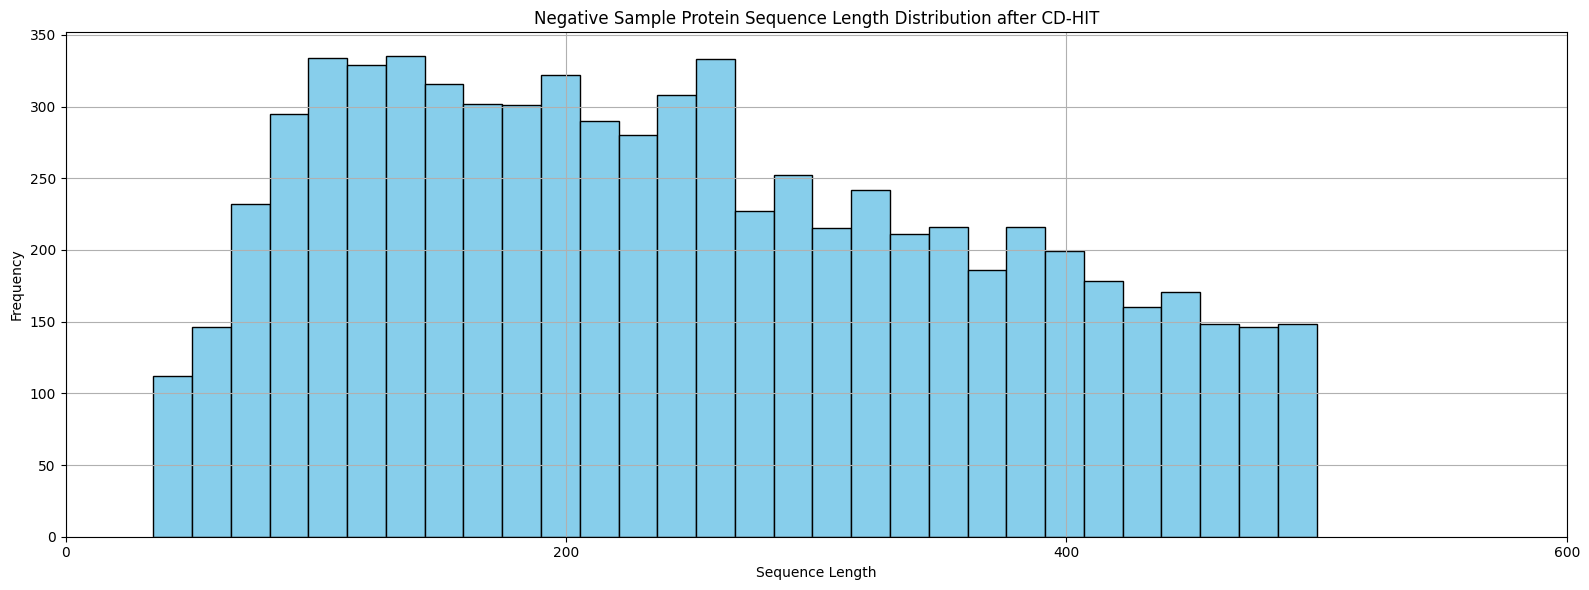

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the process_data
df = pd.read_csv("./dataset/no_lipid_binding_proteins_35_500_70.csv")

# Calculate protein sequence lengths
df["sequence_length"] = df["Sequence"].astype(str).apply(len)

# Plot histogram
plt.figure(figsize=(16, 6))
plt.hist(df["sequence_length"], bins=30, color="skyblue", edgecolor="black")
plt.title("Negative Sample Protein Sequence Length Distribution after CD-HIT")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(True)
# Set x-axis tick interval to 200
max_len = df["sequence_length"].max()
xticks = np.arange(0, max_len + 200, 200)
plt.xticks(xticks)
plt.tight_layout()
plt.savefig("./dataset/images/Negative_protein_sequence_length_distribution35_500_CD-HIT.png", dpi=300, bbox_inches='tight')
plt.show()

## 5 Merge the positive and negative sample sets
select 800 negative samples

In [54]:
import pandas as pd

# load the process_data
df_positive = pd.read_csv("./dataset/lipid_protein_4_columns_35_500.csv")
df_negative = pd.read_csv("./dataset/no_lipid_binding_proteins_35_500_70.csv")
df_positive = df_positive[['BioDolphinID', 'protein_UniProt_ID', 'Sequence','lipid_Lipidmaps_categories']]
df_negative['lipid_Lipidmaps_categories'] = 'NotLipidType'
df_negative['BioDolphinID'] = 'Negative'

In [55]:
df_positive.columns

Index(['BioDolphinID', 'protein_UniProt_ID', 'Sequence',
       'lipid_Lipidmaps_categories'],
      dtype='object')

In [56]:
df_negative.columns

Index(['protein_UniProt_ID', 'Sequence', 'lipid_Lipidmaps_categories',
       'BioDolphinID'],
      dtype='object')

In [57]:
# Get sets of IDs
set_positive = set(df_positive['protein_UniProt_ID'])
set_negative = set(df_negative['protein_UniProt_ID'])

# Find intersection 
common_ids = set_positive & set_negative

if common_ids:
    print(f"There are {len(common_ids)} common protein_UniProt_IDs:")
    print(common_ids)
else:
    print("No identical protein_UniProt_ID")

No identical protein_UniProt_ID


Randomly extract 800 samples from the negative dataset (set random_state to ensure reproducible results), vertically splice them with the positive dataset, and save the merged dataset as a CSV file

In [58]:
# Randomly select 800 samples from df_negative (without replacement)
df2_sampled = df_negative.sample(n=800, random_state=42)  # random_state ensures reproducibility
# Concatenate vertically
df_combined = pd.concat([df_positive, df2_sampled], axis=0, ignore_index=True)
df_combined.to_csv("./dataset/positive_negative_35_500.csv", index=False)

In [59]:
len(df_combined)

14047

In [60]:
df_combined.columns

Index(['BioDolphinID', 'protein_UniProt_ID', 'Sequence',
       'lipid_Lipidmaps_categories'],
      dtype='object')

In [61]:
import pandas as pd

# Read the original process_data
df = pd.read_csv("./dataset/positive_negative_35_500.csv")
# Shuffle the row order
df = df.sample(frac=1, random_state=2025).reset_index(drop=True)

# Save as a new file
df.to_csv("./dataset/positive_negative_35_500.csv", index=False)

print("Successfully rearranged column order and shuffled row order, saved as positive_negative_35_500.csv")

Successfully rearranged column order and shuffled row order, saved as positive_negative_35_500.csv


Add two columns, <b>ID</b> and <b>Label</b>. The ID naming convention is:<br/>
- Positive samples are represented by LP-1-id
- negative samples are represented by LP-0-id <br/>
The Label column is a multi-label binary classification vector.

In [62]:
import pandas as pd

# Read the process_data
df = pd.read_csv("./dataset/positive_negative_35_500.csv")

# Determine if BioDolphinID is empty and construct prefix
def generate_id(row, index):
    # Use "LP-1-" prefix if BioDolphinID exists and is not "Negative"
    prefix = "LP-1-" if pd.notna(row["BioDolphinID"]) and str(row["BioDolphinID"]).strip() != "Negative" else "LP-0-"
    return f"{prefix}{index + 1}"

# Generate ID column
df["ID"] = [generate_id(row, i) for i, row in df.iterrows()]

# Generate empty Label column
df["Label"] = ""

# Target column order
column_order = [
    'ID', 'Sequence', 'Label', 'lipid_Lipidmaps_categories', 'BioDolphinID'
]

# Reorder columns
df = df[column_order]

# Save to new file
df.to_csv("./dataset/positive_negative_35_500.csv", index=False)

print("Successfully added ID and Label columns, adjusted column order, and saved as positive_negative_35_500.csv")

Successfully added ID and Label columns, adjusted column order, and saved as positive_negative_35_500.csv


## 5 Constructing multi-hot label vectors

#### <b>5.1</b> Create a multi-label vector column
Create a multi-label vector column `Label` based on the dictionary file and the value of the `lipid_Lipidmaps_categories column`

In [63]:
import pandas as pd
import json
import numpy as np

# Load the CSV file
df = pd.read_csv('./dataset/positive_negative_35_500.csv')

# Load the category dictionary
with open('./dataset/lipid_9_category.json', 'r') as f:
    category_dict = json.load(f)

# Create a reverse mapping dictionary: category name -> index
reverse_category_map = {v: k for k, v in category_dict.items()}

# Number of categories (9-dimensional zero vector)
label_length = 9

# Define a mapping function
def map_to_labels(category_str):
    # Initialize all-zero label vector (all-zero = negative sample)
    labels = np.zeros(label_length, dtype=int)
    
    # Handle NaN or empty values
    if pd.isna(category_str) or not category_str.strip():
        return " ".join(labels.astype(str))
    
    # Split category string by commas
    categories = [cat.strip() for cat in category_str.split(',')]
    
    # Set label to 1 for each matched category
    for cat in categories:
        if cat in reverse_category_map:
            index = int(reverse_category_map[cat])
            if index < label_length:  # Ensure index is within valid range
                labels[index] = 1
    
    # Convert label vector to space-separated string
    return " ".join(labels.astype(str))

# Apply mapping function to create the 'Label' column
df['Label'] = df['lipid_Lipidmaps_categories'].apply(map_to_labels)

# Save the updated CSV file
output_path = './dataset/positive_negative_35_500.csv'
df.to_csv(output_path, index=False)

print(f"Processing complete! File saved to: {output_path}")
print(f"The new table contains {len(df.columns)} columns, with 'Label' added.")


Processing complete! File saved to: ./dataset/positive_negative_35_500.csv
The new table contains 5 columns, with 'Label' added.


In [64]:
df.columns

Index(['ID', 'Sequence', 'Label', 'lipid_Lipidmaps_categories',
       'BioDolphinID'],
      dtype='object')

In [65]:
df.head()

,ID,Sequence,Label,lipid_Lipidmaps_categories,BioDolphinID
0,LP-1-1,NSTMKTIIALSYIFCLVFADYKDDDDLEVLFQGPAMWGAGSPLAWL...,0 1 0 0 0 0 0 0 0,Fatty Acyl (FA),BD8u8f-R-R-PLM1
1,LP-1-2,KGPWQVAFIGITTGLLSLATVTGNLLVLISFKVNTELKTVNNYFLL...,0 1 0 0 1 0 0 0 0,"Fatty Acyl (FA), Sterol Lipid (ST)",BD5cxv-A-A-Y011
2,LP-1-3,MTDYIKPYNNDPFVGHLATPINSSSLTRAYLSQLPIYRRGVSPFLR...,0 0 1 0 0 0 0 0 0,Prenol Lipid (PR),BD5zgb-L-L-BCR1
3,LP-1-4,KVPTQPIPLMMNIFRDVLPTVHRYYDQWKERAKSIPDPELRAQALD...,0 0 1 0 0 0 0 0 0,Prenol Lipid (PR),BD6loo-A-A-ELR1
4,LP-1-5,SDDFLWFEGIAFPTMGFRSETLRKVRDEFVIRDEDVIILTYPKSGT...,0 0 0 0 1 0 0 0 0,Sterol Lipid (ST),BD2qp4-A-A-AOX1


#### <b>5.2</b> Handle inconsistent order of lipid type values

In [66]:
import pandas as pd

# Load process_data
df = pd.read_csv("./dataset/positive_negative_35_500.csv")

# Specify standard order dictionary (string keys)
desired_order = [
    "NotLipidType",
    "Fatty Acyl (FA)",
    "Prenol Lipid (PR)",
    "Glycerophospholipid (GP)",
    "Sterol Lipid (ST)",
    "Polyketide (PK)",
    "Glycerolipid (GL)",
    "Sphingolipid (SP)",
    "Saccharolipid (SL)"
    ]

# Build order mapping table
order_index = {label: i for i, label in enumerate(desired_order)}

print(order_index)

# Sorting function, process to string then split
def reorder_categories(cell):
    if pd.isna(cell):
        return ""
    labels = str(cell).split(",")
    labels = [x.strip() for x in labels if x.strip() != ""]
    sorted_labels = sorted(labels, key=lambda x: order_index.get(x, len(order_index)))
    return ", ".join(sorted_labels)

# Apply sorting
df['lipid_Lipidmaps_categories'] = df['lipid_Lipidmaps_categories'].apply(reorder_categories)

# Save results
output_path = "./dataset/reordered_lipid_categories.csv"
df.to_csv(output_path, index=False)

print(f"lipid_Lipidmaps_categories has been reordered and saved to: {output_path}")
    

{'NotLipidType': 0, 'Fatty Acyl (FA)': 1, 'Prenol Lipid (PR)': 2, 'Glycerophospholipid (GP)': 3, 'Sterol Lipid (ST)': 4, 'Polyketide (PK)': 5, 'Glycerolipid (GL)': 6, 'Sphingolipid (SP)': 7, 'Saccharolipid (SL)': 8}
lipid_Lipidmaps_categories has been reordered and saved to: ./dataset/reordered_lipid_categories.csv


Category distribution of statistical samples

##### Handling of minority samples

Copy samples with a label class that appears less than 50 times to a new file and delete them from the original dataset. This prevents rare samples from interfering with the training process. However, these samples are still valuable and can be used for subsequent model validation.

In [68]:
import pandas as pd

# Load the process_data
df = pd.read_csv("./dataset/reordered_lipid_categories.csv")

# Step 1: Calculate frequency of all category combinations (as entire strings)
comb_counts = df['lipid_Lipidmaps_categories'].value_counts()

# Step 2: Identify category combinations with occurrence count < 50
rare_combinations = comb_counts[comb_counts < 50].index.tolist()

# Step 3: Save samples with rare combinations separately
rare_df = df[df['lipid_Lipidmaps_categories'].isin(rare_combinations)]
rare_df.to_csv("./dataset/rare_combinations_35_500.csv", index=False)

# Step 4: Remove samples with these rare combinations from original process_data
filtered_df = df[~df['lipid_Lipidmaps_categories'].isin(rare_combinations)]
filtered_df.to_csv("./dataset/filtered_positive_negative_35_500.csv", index=False)

print(f"Number of rare combination samples: {len(rare_df)}, saved as rare_combinations_35_500.csv")
print(f"Number of remaining samples: {len(filtered_df)}, saved as filtered_positive_negative_35_500.csv")

Number of rare combination samples: 374, saved as rare_combinations_35_500.csv
Number of remaining samples: 13673, saved as filtered_positive_negative_35_500.csv


This file <b> `rare_combinations_35_500.csv` </b> can be used to test the model in the future. Like the test set, the model has not seen these samples. Unlike the test set, the model has never seen these label combinations, so this data is extremely valuable.

## 6 Dataset splitting

<b>Note:</b> In order to maintain the consistency of the label distribution of the training set and the test set, the dataset is divided according to the label distribution

In [70]:
import pandas as pd
import numpy as np
from skmultilearn.model_selection import IterativeStratification   # pip install scikit-multilearn

# ---------- Config ----------
data_path = "./dataset/filtered_positive_negative_35_500.csv"  # Full dataset path
label_column = "Label"                # Column name for multi-hot labels
train_ratio = 0.9                      # Train set ratio
save_train = "./processed/train_dataset.csv"
save_test = "./processed/test_dataset.csv"

# ---------- Step 1: Load dataset ----------
df = pd.read_csv(data_path)

def parse_label_column(label_str):
    """
    Convert the label string into a numpy array of integers.
    Handles both space-separated and character-separated formats.
    """
    label_str = str(label_str).strip()
    if ' ' in label_str:
        return np.array([int(x) for x in label_str.split()])
    else:
        return np.array([int(x) for x in label_str])

labels = np.stack(df[label_column].apply(parse_label_column).values)  # shape = [N, L]
X = np.arange(len(df)).reshape(-1, 1)  # dummy features (only for indexing)

# ---------- Step 2: Iterative stratified split ----------
splitter = IterativeStratification(
    n_splits=2,
    order=1,
    sample_distribution_per_fold=[train_ratio, 1 - train_ratio]
)

test_idx, train_idx = next(splitter.split(X, labels))
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# ---------- Step 3: Save split results ----------
train_df.to_csv(save_train, index=False)
test_df.to_csv(save_test, index=False)
print(f"Data split completed. Train set: {len(train_df)} samples, Test set: {len(test_df)} samples")

# ---------- Step 4: Check label distribution ----------
def label_stats(df):
    """
    Compute mean occurrence of each label across the dataset.
    """
    arr = np.stack(df[label_column].apply(parse_label_column).values)
    return arr.mean(axis=0)

train_dist = label_stats(train_df)
test_dist = label_stats(test_df)

print(f"Train set label mean distribution: {np.round(train_dist, 4)}")
print(f"Test set label mean distribution:  {np.round(test_dist, 4)}")
print(f"Absolute difference:               {np.round(np.abs(train_dist - test_dist), 4)}")


Data split completed. Train set: 12296 samples, Test set: 1377 samples
Train set label mean distribution: [0.0586 0.4687 0.213  0.1832 0.1168 0.1071 0.043  0.0129 0.0064]
Test set label mean distribution:  [0.0581 0.4648 0.2113 0.1816 0.1162 0.106  0.0428 0.0131 0.0065]
Absolute difference:               [0.0005 0.0039 0.0017 0.0017 0.0006 0.0011 0.0002 0.0001 0.0001]


In [71]:
len(train_df),len(test_df)

(12296, 1377)

Determine the consistency of the label distribution of two data sets

In [72]:
import pandas as pd
import numpy as np

def compute_label_distribution(df, label_column='Label'):
    """
    Calculate label distribution: returns the mean value for each label position
    """
    label_array = np.stack(df[label_column].apply(parse_label_column).values)
    return label_array.mean(axis=0)  # shape: [num_labels]

def compare_distributions(dist1, dist2, tol=1e-3):
    """
    Compare if two label distributions are consistent (per-dimension error < tol)
    """
    diff = np.abs(dist1 - dist2)
    return diff, np.all(diff < tol)

def check_label_distribution(csv1_path, csv2_path, label_column='Label', tol=1e-3):
    df1 = pd.read_csv(csv1_path)
    df2 = pd.read_csv(csv2_path)

    dist1 = compute_label_distribution(df1, label_column)
    dist2 = compute_label_distribution(df2, label_column)

    diff, is_consistent = compare_distributions(dist1, dist2, tol)

    print(f"Dataset 1 label distribution means: {np.round(dist1, 4)}")
    print(f"Dataset 2 label distribution means: {np.round(dist2, 4)}")
    print(f"Per-dimension distribution differences:     {np.round(diff, 4)}")
    print(f"\nLabel distributions are consistent: {is_consistent}")

    return is_consistent

check_label_distribution("processed/train_dataset.csv", "processed/test_dataset.csv", label_column='Label', tol=0.01)

Dataset 1 label distribution means: [0.0586 0.4687 0.213  0.1832 0.1168 0.1071 0.043  0.0129 0.0064]
Dataset 2 label distribution means: [0.0581 0.4648 0.2113 0.1816 0.1162 0.106  0.0428 0.0131 0.0065]
Per-dimension distribution differences:     [0.0005 0.0039 0.0017 0.0017 0.0006 0.0011 0.0002 0.0001 0.0001]

Label distributions are consistent: True


True

## 7 Calculate the weight of each type in different data sets

In [74]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Dataset
import pandas as pd
import torch

class SequenceMultiLabelDataset(Dataset):
    def __init__(self, csv_file):
        # Initialize dataset by reading CSV file
        self.data = pd.read_csv(csv_file)

    def __len__(self):
        # Return total number of samples in the dataset
        return len(self.data)

    def label_to_vector(self, label_str):
        # Convert label string to binary vector (0/1 tensor)
        return torch.tensor([int(x) for x in label_str.split()], dtype=torch.int32)

    def __getitem__(self, idx):
        # Get sequence (string) from the dataset
        sequence = self.data.iloc[idx]['Sequence']
        # Get label string and convert to 0/1 vector
        label_vector = self.label_to_vector(self.data.iloc[idx]['Label'])

        return sequence, label_vector

In [75]:
# Instantiate datasets
train_dataset = SequenceMultiLabelDataset("processed/train_dataset.csv")
test_dataset = SequenceMultiLabelDataset("processed/test_dataset.csv")

# Build DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [76]:
# Load label mapping
with open("./dataset/lipid_9_category.json", "r") as f:
    category_mapping = json.load(f)
# Calculate training set weights
compute_class_weights(train_loader, category_mapping, save_path="processed", filename="train_class_weight.json")


Multi-label class distribution and weights:
NotLipidType: 720 positive samples | 5.86% | weight: 1.8975
Fatty Acyl (FA): 5763 positive samples | 46.87% | weight: 0.2371
Prenol Lipid (PR): 2619 positive samples | 21.30% | weight: 0.5217
Glycerophospholipid (GP): 2253 positive samples | 18.32% | weight: 0.6064
Sterol Lipid (ST): 1436 positive samples | 11.68% | weight: 0.9514
Polyketide (PK): 1317 positive samples | 10.71% | weight: 1.0374
Glycerolipid (GL): 529 positive samples | 4.30% | weight: 2.5827
Sphingolipid (SP): 159 positive samples | 1.29% | weight: 8.5926
Saccharolipid (SL): 79 positive samples | 0.64% | weight: 17.2940

Class weights saved to: processed\train_class_weight.json


tensor([ 1.8975,  0.2371,  0.5217,  0.6064,  0.9514,  1.0374,  2.5827,  8.5926,
        17.2940])

In [77]:
# Calculate testing set weights  
compute_class_weights(test_loader, category_mapping, save_path="processed", filename="test_class_weight.json")


Multi-label class distribution and weights:
NotLipidType: 80 positive samples | 5.81% | weight: 1.9125
Fatty Acyl (FA): 640 positive samples | 46.48% | weight: 0.2391
Prenol Lipid (PR): 291 positive samples | 21.13% | weight: 0.5258
Glycerophospholipid (GP): 250 positive samples | 18.16% | weight: 0.6120
Sterol Lipid (ST): 160 positive samples | 11.62% | weight: 0.9563
Polyketide (PK): 146 positive samples | 10.60% | weight: 1.0479
Glycerolipid (GL): 59 positive samples | 4.28% | weight: 2.5932
Sphingolipid (SP): 18 positive samples | 1.31% | weight: 8.5000
Saccharolipid (SL): 9 positive samples | 0.65% | weight: 17.0000

Class weights saved to: processed\test_class_weight.json


tensor([ 1.9125,  0.2391,  0.5258,  0.6120,  0.9563,  1.0479,  2.5932,  8.5000,
        17.0000])

### <font color = "red">Congratulations</font>, You have successfully created the training and test datasets!